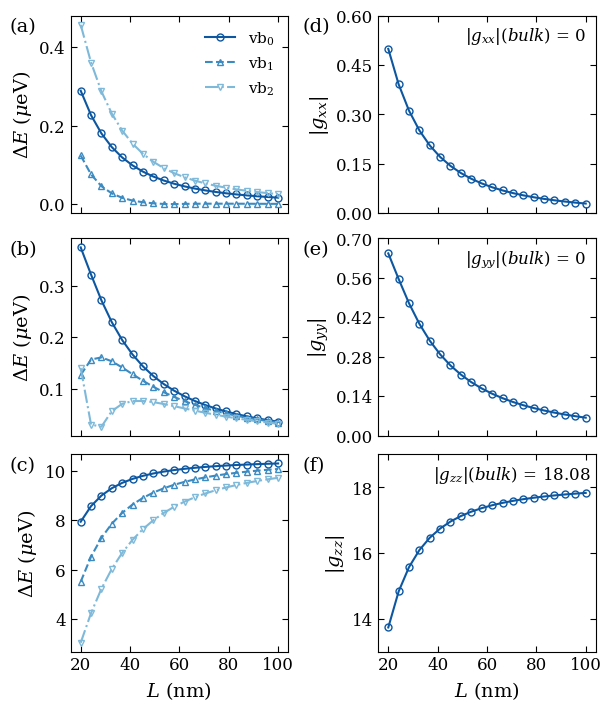

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ==================================================
# Global plot settings
# ==================================================
plt.rcParams.update({
    "figure.figsize": [6, 8],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
})

# ==================================================
# Load Data
# ==================================================
N = 100

size_x, gfactorx, gapvb0x, gapvb1x, gapvb2x, gapcbx, gcbx = np.loadtxt(
    f"full_gfactor_x_N{N}.dat", unpack=True
)
size_y, gfactory, gapvb0y, gapvb1y, gapvb2y, gapcby, gcby = np.loadtxt(
    f"full_gfactor_y_N{N}.dat", unpack=True
)
size_z, gfactorz, gapvb0z, gapvb1z, gapvb2z, gapcbz, gcbz = np.loadtxt(
    f"full_gfactor_z_N{N}.dat", unpack=True
)

sx, sy, sz = size_x, size_y, size_z

# ==================================================
# Colors and styles
# ==================================================
cmap = plt.cm.Blues
colors = cmap([0.85, 0.65, 0.45])

markers = ["o", "^", "v"]
linestyles = ["-", "--", "-."]
labels = [r"vb$_0$", r"vb$_1$", r"vb$_2$"]

# ==================================================
# Create 3x2 Combined Figure
# ==================================================
fig, axes = plt.subplots(
    3, 2,
    figsize=(6, 7),
    constrained_layout=True,
    sharex=True
)

# ==================================================
# LEFT COLUMN: Gap plots (a), (b), (c)
# ==================================================
gap_data = [
    (sx, (gapvb0x * 1e6, gapvb1x * 1e6, gapvb2x * 1e6), "(a)"),
    (sy, (gapvb0y * 1e6, gapvb1y * 1e6, gapvb2y * 1e6), "(b)"),
    (sz, (gapvb0z * 1e6, gapvb1z * 1e6, gapvb2z * 1e6), "(c)"),
]

for i, (s, gaps, tag) in enumerate(gap_data):
    ax = axes[i, 0]

    for g, m, ls, lbl, col in zip(gaps, markers, linestyles, labels, colors):
        ax.plot(
            s, g,
            marker=m,
            linestyle=ls,
            color=col,
            markersize=5,
            markerfacecolor="none",
            markeredgewidth=1.0,
            linewidth=1.5,
            label=lbl
        )

    if i == 0:
        ax.legend(frameon=False)
        # ax.text(
        #     0.45, 0.50,
        #     r"|B| = 0.01 T",
        #     transform=ax.transAxes,
        #     fontsize=12
        # )

    if i == 2:
        ax.set_xlabel(r"$L$ (nm)")

    ax.set_ylabel(r"$\Delta E$ ($\mu$eV)")
    ax.text(-0.28, 0.92, tag, transform=ax.transAxes, fontsize=14)
    # ax.minorticks_on()

# ==================================================
# RIGHT COLUMN: G-factor plots (d), (e), (f)
# ==================================================
n = 2

def g_fit(L, g0, b):
    return g0 + b / L**n


g_data = [
    (sx, gfactorx, "(d)", r"$|g_{xx}|$"),
    (sy, gfactory, "(e)", r"$|g_{yy}|$"),
    (sz, gfactorz, "(f)", r"$|g_{zz}|$"),
]

for i, (s, g, tag, ylabel) in enumerate(g_data):
    ax = axes[i, 1]

    ax.plot(
        s, g,
        marker="o",
        linestyle="-",
        color=colors[0],
        markersize=5,
        markerfacecolor="none",
        markeredgewidth=1.0,
        linewidth=1.5
    )

    ax.set_ylabel(ylabel)

    if i == 0:
        # ax.legend(frameon=False)
        ax.set_yticks(np.linspace(0, 0.6, 5))
        ax.set_ylim(0, 0.6)
        ax.set_xticks([20, 40, 60, 80, 100])
        ax.text(
            0.40, 0.95,
            r"$|g_{xx}| (bulk)$ = 0",
            transform=ax.transAxes,
            va="top",
            fontsize=12
        )

    if i == 1:
        ax.set_yticks(np.linspace(0, 0.7, 6))
        ax.set_ylim(0, 0.7)
        ax.text(
            0.40, 0.95,
            r"$|g_{yy}| (bulk)$ = 0",
            transform=ax.transAxes,
            va="top",
            fontsize=12
        )

    if i == 2:
        ax.set_xlabel(r"$L$ (nm)")
        ax.set_ylim(13, 19)
        ax.set_yticks(np.linspace(14, 18, 3))
        ax.text(
            0.25, 0.95,
            r"$|g_{zz}| (bulk)$ = 18.08",
            transform=ax.transAxes,
            va="top",
            fontsize=12
        )

    ax.text(-0.35, 0.92, tag, transform=ax.transAxes, fontsize=14)
    # ax.minorticks_on()

# ==================================================
# Save Figures
# ==================================================
fig.savefig("Zeeman_splittings.png", dpi=300, bbox_inches="tight")
fig.savefig("Zeeman_splittings.pdf", bbox_inches="tight")
fig.savefig("Zeeman_splittings.svg", bbox_inches="tight")

plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# Global plot settings
# ==================================================
plt.rcParams.update({
    "figure.figsize": [10, 5.5],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
})

# ==================================================
# Load Data
# ==================================================
N = 100

size_x, gfactorx, gapvb0x, gapvb1x, gapvb2x = np.loadtxt(
    f"full_gfactor_x_N{N}.dat", unpack=True
)
size_y, gfactory, gapvb0y, gapvb1y, gapvb2y = np.loadtxt(
    f"full_gfactor_y_N{N}.dat", unpack=True
)
size_z, gfactorz, gapvb0z, gapvb1z, gapvb2z = np.loadtxt(
    f"full_gfactor_z_N{N}.dat", unpack=True
)

sx, sy, sz = size_x, size_y, size_z

# ==================================================
# Colors and styles
# ==================================================
cmap = plt.cm.Blues
colors = cmap([0.85, 0.65, 0.45])

markers = ["o", "^", "v"]
linestyles = ["-", "--", "-."]
labels = [r"VB$_0$", r"VB$_1$", r"VB$_2$"]

# ==================================================
# Create 2x3 Combined Figure
# ==================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(10, 4),
    constrained_layout=True,
    sharex=True
)

# ==================================================
# TOP ROW: Gap plots (a), (b), (c)
# ==================================================
gap_data = [
    (sx, (gapvb0x * 1e6, gapvb1x * 1e6, gapvb2x * 1e6), "(a)", r"$\Delta E_x$"),
    (sy, (gapvb0y * 1e6, gapvb1y * 1e6, gapvb2y * 1e6), "(b)", r"$\Delta E_y$"),
    (sz, (gapvb0z * 1e6, gapvb1z * 1e6, gapvb2z * 1e6), "(c)", r"$\Delta E_z$"),
]

for j, (s, gaps, tag, ylabel_text) in enumerate(gap_data):
    ax = axes[0, j]

    for g, m, ls, lbl, col in zip(gaps, markers, linestyles, labels, colors):
        ax.plot(
            s, g,
            marker=m,
            linestyle=ls,
            color=col,
            markersize=5,
            markerfacecolor="none",
            markeredgewidth=1.0,
            linewidth=1.5,
            label=lbl
        )

    if j == 0:
        ax.legend(frameon=False)
        ax.text(
            0.45, 0.50,
            r"|B| = 0.01 T",
            transform=ax.transAxes,
            fontsize=12
        )

    ax.set_ylabel(ylabel_text + r" ($\mu$eV)")
    ax.text(0.04, 0.92, tag, transform=ax.transAxes, fontsize=14)
    # ax.minorticks_on()

# ==================================================
# BOTTOM ROW: G-factor plots (d), (e), (f)
# ==================================================
g_data = [
    (sx, gfactorx, "(d)", r"$|g^x_{||}|$"),
    (sy, gfactory, "(e)", r"$|g^y_{\perp}|$"),
    (sz, gfactorz, "(f)", r"$|g^z_{\perp}|$"),
]

for j, (s, g, tag, ylabel) in enumerate(g_data):
    ax = axes[1, j]

    ax.plot(
        s, g,
        marker="o",
        linestyle="-",
        color=colors[0],
        markersize=5,
        markerfacecolor="none",
        markeredgewidth=1.0,
        linewidth=1.5
    )

    ax.set_ylabel(ylabel)
    ax.set_xlabel(r"$L$ (nm)")

    if j == 0:
        ax.set_yticks(np.linspace(0, 0.48, 4))
        ax.set_ylim(0, 0.55)
        ax.set_xticks([20, 40, 60, 80, 100])
        ax.text(
            0.40, 0.95,
            r"$g^x_{||} (bulk)$ = 0",
            transform=ax.transAxes,
            va="top",
            fontsize=12
        )

    if j == 1:
        ax.set_yticks(np.linspace(0, 0.75, 4))
        ax.set_ylim(0, 0.75)
        ax.text(
            0.40, 0.95,
            r"$g^y_{\perp} (bulk)$ = 0",
            transform=ax.transAxes,
            va="top",
            fontsize=12
        )

    if j == 2:
        ax.set_ylim(13, 19)
        ax.set_yticks(np.linspace(14, 18, 3))
        ax.text(
            0.30, 0.95,
            r"$g^z_{\perp} (bulk)$ = 18.06",
            transform=ax.transAxes,
            va="top",
            fontsize=12
        )

    ax.text(0.04, 0.92, tag, transform=ax.transAxes, fontsize=14)
    # ax.minorticks_on()

# ==================================================
# Save Figures
# ==================================================
fig.savefig("Zeeman_splittings_2x3.png", dpi=300, bbox_inches="tight")
fig.savefig("Zeeman_splittings_2x3.pdf", bbox_inches="tight")

plt.show()

ValueError: too many values to unpack (expected 5)

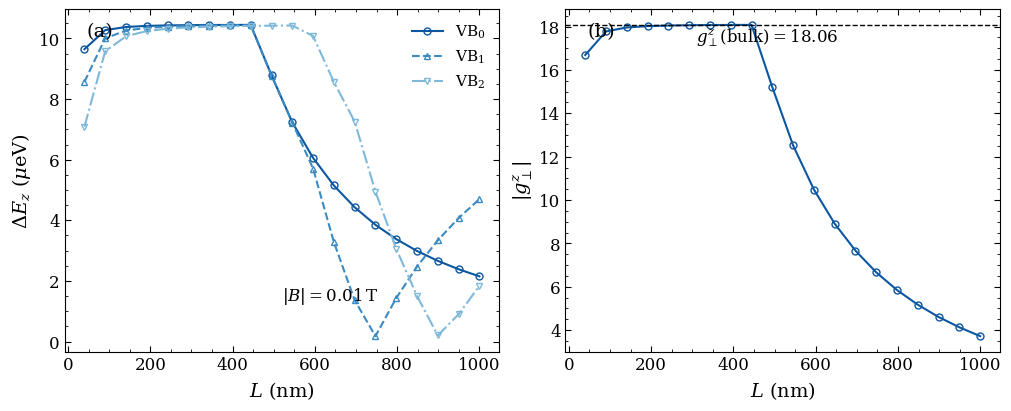

In [ ]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4),
    constrained_layout=True,
    sharex=True
)

# ==========================================
# Left panel: Zeeman splittings
# ==========================================
ax = axes[0]

gaps = [gapvb0z * 1e6, gapvb1z * 1e6, gapvb2z * 1e6]

for g, m, ls, lbl, col in zip(
        gaps, markers, linestyles, labels, colors):

    ax.plot(
        sz, g,
        marker=m,
        linestyle=ls,
        color=col,
        markersize=5,
        markerfacecolor="none",
        markeredgewidth=1.0,
        linewidth=1.5,
        label=lbl
    )

ax.set_xlabel(r"$L$ (nm)")
ax.set_ylabel(r"$\Delta E_z$ ($\mu$eV)")

ax.legend(frameon=False)

ax.text(
    0.05, 0.92,
    "(a)",
    transform=ax.transAxes,
    fontsize=14
)

ax.text(
    0.50, 0.15,
    r"$|B| = 0.01\,\mathrm{T}$",
    transform=ax.transAxes,
    fontsize=12
)

ax.minorticks_on()

# ==========================================
# Right panel: g-factor
# ==========================================
ax = axes[1]

ax.plot(
    sz, gfactorz,
    marker="o",
    linestyle="-",
    color=colors[0],
    markersize=5,
    markerfacecolor="none",
    markeredgewidth=1.0,
    linewidth=1.5
)

ax.axhline(
    y=18.06,
    linestyle="--",
    color="k",
    linewidth=1
)

ax.set_xlabel(r"$L$ (nm)")
ax.set_ylabel(r"$|g^z_{\perp}|$")

ax.text(
    0.05, 0.92,
    "(b)",
    transform=ax.transAxes,
    fontsize=14
)

ax.text(
    0.30, 0.95,
    r"$g^z_{\perp} (\mathrm{bulk}) = 18.06$",
    transform=ax.transAxes,
    va="top",
    fontsize=12
)

ax.minorticks_on()

# # Optional: consistent x-axis ticks
# for ax in axes:
#     ax.set_xticks([20, 40, 60, 80, 100])

plt.show()